## NIMOハンズオン (関数の最適化)

In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "physbo_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "/Users/shibukawar/workspace/nimo-fork/multi_batch_experiments_melting_temperature/./configs/physbo_batch1_trial3.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from al_mg_zn import AlMgZnMeltingPoint
des = AlMgZnMeltingPoint()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = config["batch_size"]
TOTAL_EVAL = config["total_eval"]
INITIAL_BATCH_SIZE = config["initial_batch_size"]
print(f"Initial Batch Size: {INITIAL_BATCH_SIZE}")
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

# Create output directory with batch size in name
out_dir = Path(f"./data_physbo_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

Initial Batch Size: 15
CyclesNum: 30


PosixPath('data_physbo_batch1_trial3/physbo_batch1_trial3.yaml')

In [9]:
candidates_file = out_dir / f"mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"mp_proposals_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    #PHYSBO: ベイズ最適化
    #BLOX: 無目的探索
    #PDC: 相図探索
    #RE: ランダム
    else:
        nimo.selection(method = "PHYSBO",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    #今回は，inputfile.txtファイルを作成するだけのモジュール
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()


    #実験終了後，測定データを解析し，目的関数をアップデートする
    #今回は，関数値を計算し，目的関数とするanalysis_output_functions.pyを利用する
    import analysis_output_functions_SO_melting_point
    analysis_output_functions_SO_melting_point.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

    #結果の相図を作成するモジュールを読み出す
    #if K % 5 == 0:
    #    import time
    #    time.sleep(1)
    #    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file,
    #                                               fig_folder = "./fig")
end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!
Proposals
###
number = 1
actions =  435
proposal =  [18. 24.]
###
###
number = 2
actions =  647
proposal =  [28. 48.]
###
###
number = 3
actions =  1011
proposal =  [52. 20.]
###
###
number = 4
actions =  397
proposal =  [16. 34.]
###
###
number = 5
actions =  814
proposal =  [38. 32.]
###
###
number = 6
actions =  853
proposal =  [40. 46.]
###
###
number = 7
actions =  1263
proposal =  [80.  6.]
###
###
number = 8
actions =  347
proposal =  [14. 22.]
###
###
number = 9
actions =  1289
proposal =  [84. 16.]
###
###
number = 10
actions =  396
proposal =  [16. 32.]
###
###
number = 11
actions =  863
proposal =  [42.  4.]
###
###
number = 12
actions =  1145
proposal =  [64. 18.]
###
###
number = 13
actions =  470
proposal =  [20. 10.]
###
###
number = 14
actions =  375
proposal =  [14. 78.]
###
###
number = 15
actions =  948
proposal =  [48.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!

Start selection of proposals by PHYSBO!
49268067
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 72.8174524547553
50 -th epoch marginal likelihood 72.65932815261266
100 -th epoch marginal likelihood 72.54544257319287
150 -th epoch marginal likelihood 72.47041031886233
200 -th epoch marginal likelihood 72.41988450298926
250 -th epoch marginal likelihood 72.38091784632773
300 -th epoch marginal likelihood 72.34688424265906
350 -th epoch marginal likelihood 72.3156319709753
400 -th epoch marginal likelihood 72.28660026963837
450 -th epoch marginal likelihood 72.25957966984762
500 -th epoch marginal likelihood 72.23442467856069
Done



Proposals
###
number = 1
actions =  1295
proposal =  [86. 10.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
953613539
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 78.00401737436432
50 -th epoch marginal likelihood 77.62466787477315
100 -th epoch marginal likelihood 77.33890153253122
150 -th epoch marginal likelihood 77.10675821227454
200 -th epoch marginal likelihood 76.90476206487861
250 -th epoch marginal likelihood 76.73188063688302
300 -th epoch marginal likelihood 76.59038700419293
350 -th epoch marginal likelihood 76.47960667696606
400 -th epoch marginal likelihood 76.39570422012018
450 -th epoch marginal likelihood 76.33297829498122


...

Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 203.1787060707815
50 -th epoch marginal likelihood 201.05086943561702
100 -th epoch marginal likelihood 199.2668812775492
150 -th epoch marginal likelihood 197.7503880194784
200 -th epoch marginal likelihood 196.46317702971686
250 -th epoch marginal likelihood 195.41027018971204
300 -th epoch marginal likelihood 194.57297191652214
350 -th epoch marginal likelihood 193.90600531617818


400 -th epoch marginal likelihood 193.35644567274468
450 -th epoch marginal likelihood 192.87996771677
500 -th epoch marginal likelihood 192.44682134672328
Done

Proposals
###
number = 1
actions =  545
proposal =  [22. 78.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
1621547682
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 204.12397591362182
50 -th epoch marginal likelihood 202.27523066680706
100 -th epoch marginal likelihood 200.94493491550463
150 -th epoch marginal likelihood 199.90175387026358
200 -th epoch marginal likelihood 199.07593100147875
250 -th epoch marginal likelihood 198.41880689294263
300 -th epoch marginal likelihood 197.87107838430495
350 -th epoch marginal likelihood 197.38594730486946
400 -th epoch marginal likelihood 196.93547708188308


450 -th epoch marginal likelihood 196.50615736037275
500 -th epoch marginal likelihood 196.09256575519387
Done

Proposals
###
number = 1
actions =  1000
proposal =  [50. 50.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!


Elapsed time: 57.35771870613098 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])


Text(0, 0.5, 'Objective')

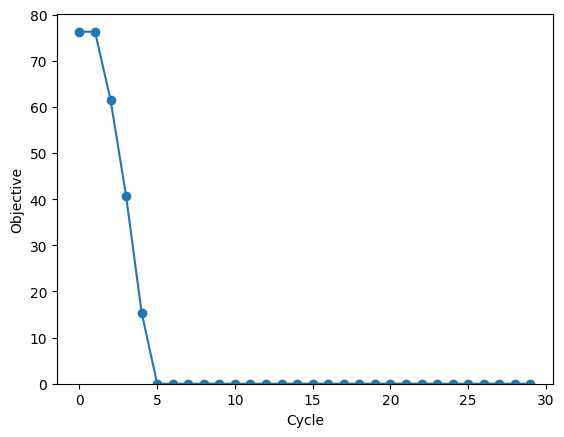

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)